# EDA

In [1]:
import pandas as pd

df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

### Shape

In [2]:
print(df.shape)

(1470, 35)


### Tipi

In [3]:
print(df.dtypes)

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

### Valori Null

In [4]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

## Considerazioni

In [5]:
print(df["Attrition"].value_counts(normalize=True) * 100)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


Il dataset non è bilanciato. Un modello allenato con questo dataset può risultare preciso all'84% predicendo sempre "No".

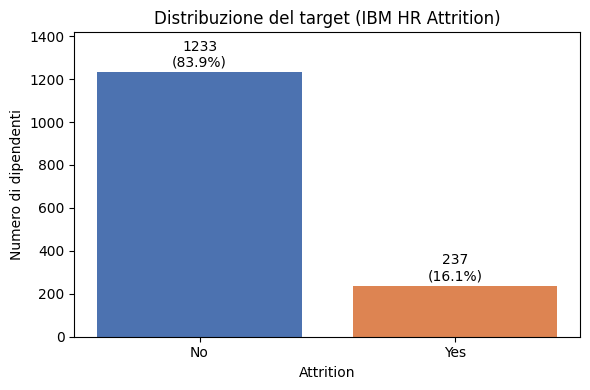

In [6]:
import matplotlib.pyplot as plt
import os

os.makedirs("output/eda", exist_ok=True)

attrition_counts = df["Attrition"].value_counts()
attrition_pct = df["Attrition"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    attrition_counts.index,
    attrition_counts.values,
    color=["#4C72B0", "#DD8452"],
)
ax.set_ylabel("Numero di dipendenti")
ax.set_xlabel("Attrition")
ax.set_title("Distribuzione del target (IBM HR Attrition)")

for bar, label, pct in zip(bars, attrition_counts.values, attrition_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f"{label}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_ylim(0, attrition_counts.max() * 1.15)
plt.tight_layout()
plt.savefig("output/eda/eda_class_balance.png", bbox_inches="tight", dpi=150)
plt.show()

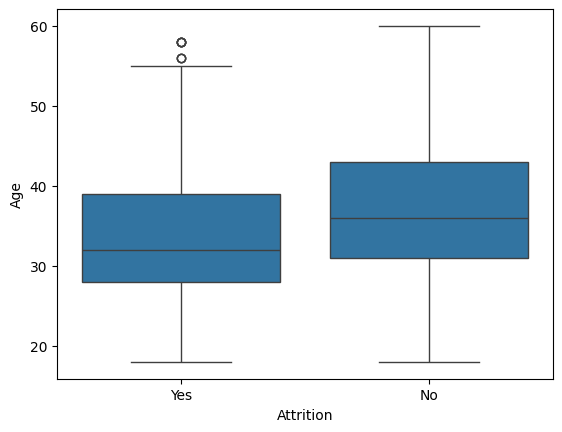

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("output", exist_ok=True)

sns.boxplot(data=df, x="Attrition", y="Age")
plt.savefig("output/eda_age_vs_attrition.png", bbox_inches="tight", dpi=150)
plt.show()


Il grafico mostra che l'età è un fattore correlato all'abbandono di un dipendente dall'azienda. I dipendenti più giovani hanno statisticamente più flessibilità economica che li spinge a cercare nuove opportunità lavorative.

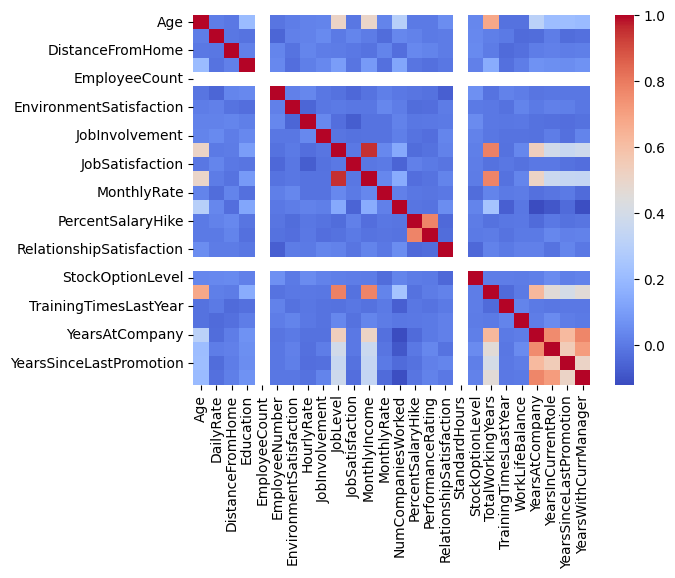

In [8]:
numeric_df = df.select_dtypes(include="number")
sns.heatmap(numeric_df.corr(), cmap="coolwarm", fmt=".1f")
plt.savefig("output/eda_correlation_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()


Nella heatmap notiamo correlazioni tra le features:
- YearsAtCompany
- YearsInCurrentRole
- YearsSinceLastPromotion
- YearsWithCurrManager

Questo può indicare una correlazione diretta tra lo "stallo" del dipendente e l'abbandono dell'azienda.